In [9]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import statistics
import re
import copy


def set_size(fraction_width=0.95, fraction_height=0.25):
    width_pt = 241.14749 # column width in pt
    height_pt = 626.0 # page height in pt

    fig_width_pt = width_pt * fraction_width
    fig_height_pt = height_pt * fraction_height
    inches_per_pt = 1 / 72.27

    fig_width_in = fig_width_pt * inches_per_pt
    fig_height_in = fig_height_pt * inches_per_pt

    return fig_width_in, fig_height_in


width = 0.1

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

# Set default background color for the plot area (axes)
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['xtick.color'] = 'black'     
plt.rcParams['ytick.color'] = 'black'      
plt.rcParams['axes.labelcolor'] = 'black'    
plt.rcParams['axes.edgecolor'] = 'black'     
plt.rcParams['font.size'] = '25'

def create_dict():
    return {"Execution": [], "Optimization": []}

colors = {'ResultDB_Decompose': 'blue', 'ResultDB_SemiJoin':'green', 'TD_Root': 'brown', 'TD_Fold': 'red', 'TD_Fold_NoTVC': 'orange', 'TD_ResultDB': 'violet', 'DP_ResultDB_Greedy': 'violet', 'DP_ResultDB_Exhaustive': 'red', 'GHD_Heuristic': 'pink', 'GHD_C_Fold': "#997700"}
alg_to_latex = {'ResultDB_Decompose': r'ResultDB$_{\text{Decompose}}$', 'ResultDB_SemiJoin': r'ResultDB$_{\text{Semi-Join}}$','TD_Root': r'TD$_{\text{Root}}$', 'TD_Fold': r'TD$_{\text{Fold}}$', 'TD_Fold_NoTVC': r'TD$_{\text{Fold-NoTVC}}$', 'TD_ResultDB': r'TD$_{\text{ResultDB}}$', 'DP_ResultDB_Greedy': r'DP$_{\text{ResultDB\_Greedy}}$', 'DP_ResultDB_Exhaustive': r'DP$_{\text{ResultDB\_Exhaustive}}$', 'GHD_Heuristic': r'GHD$_{\text{Heuristic}}$', 'GHD_C_Fold': r'GHD$_{\text{CostModel}}$'}


# !!!!!!!!!!!!!!!!!!!!!!!! ATTENTION !!!!!!!!!!!!!!!!!!!!!!!!
# If you want to create the visualization for the existing results in the repository, set the parameter 'use_existing_results' to 'True',
# if you want to create the visualization for the newly results in your rerun of the experiments, set it to 'False'
use_existing_results: bool = True
# !!!!!!!!!!!!!!!!!!!!!!!! ATTENTION !!!!!!!!!!!!!!!!!!!!!!!!
result_path: str = "existing_results" if use_existing_results else "recreated_results"

acyclic_algorithms = ["ResultDB_Decompose", "ResultDB_SemiJoin", "TD_Root", "TD_ResultDB"]
cyclic_algorithms = ["ResultDB_Decompose", "ResultDB_SemiJoin", "GHD_Heuristic", "GHD_C_Fold", "TD_Fold", "TD_Fold_NoTVC", "TD_ResultDB"]

def get_name_for_algorithm(algorithm: str):
    # algorithm = mutable (single core, <actual_name>)
    match = re.search(r'\(([^)]*)\)', algorithm)
    paran_name = match.group(1)
    return paran_name.split(",")[1][1:]


def create_ax_for_benchmark(ax, path: str, algorithms: list[str], bar_width, lines, queries, labels, search_string: str, log_scale=True):
    algorithms_times = {alg: [] for alg in algorithms}
    ax.yaxis.grid(color='gray', linestyle='dashed')
    if log_scale:
        ax.set_yscale('log')

    data = pd.read_csv(path)
    data = (data.groupby(by=['commit', 'date', 'version', 'suite', 'benchmark', 'experiment', 'name', 'config', 'case',], as_index=False)
                .median()
                .drop(['commit', 'date', 'version', 'suite', 'benchmark', 'runid'], axis=1)
        )

    x = np.arange(len(queries))
    for query in queries:
        # Get Results for each query
        size_data = data[data[search_string] == query]

        for _, row in size_data.iterrows():
            algorithm = get_name_for_algorithm(row['name'])
            execution_time = row['time']
            algorithms_times[algorithm].append(execution_time)

    multiplier = 0

    for algorithm, time in algorithms_times.items():
        offset = bar_width * multiplier
        lines[algorithm] = ax.bar(x + offset, time, width, label=alg_to_latex[algorithm], color=colors[algorithm])
        multiplier += 1

    ax.set_xticks(x + ((len(algorithms) / 2) - 0.5) * bar_width, labels)
    ax.set_axisbelow(True)

    return algorithms_times

# Enumeration Time Experiments

   experiment                                       name          config  \
0       cycle          mutable (single core, GHD_C_Fold)  Execution Time   
1       cycle          mutable (single core, GHD_C_Fold)  Execution Time   
2       cycle          mutable (single core, GHD_C_Fold)  Execution Time   
3       cycle          mutable (single core, GHD_C_Fold)  Execution Time   
4       cycle       mutable (single core, GHD_Heuristic)  Execution Time   
5       cycle       mutable (single core, GHD_Heuristic)  Execution Time   
6       cycle       mutable (single core, GHD_Heuristic)  Execution Time   
7       cycle       mutable (single core, GHD_Heuristic)  Execution Time   
8       cycle  mutable (single core, ResultDB_Decompose)  Execution Time   
9       cycle  mutable (single core, ResultDB_Decompose)  Execution Time   
10      cycle  mutable (single core, ResultDB_Decompose)  Execution Time   
11      cycle  mutable (single core, ResultDB_Decompose)  Execution Time   
12      cycl

/var/folders/9n/q6f4_f3x1v10_ss5pw11tkww0000gn/T/ipykernel_97823/2649226516.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


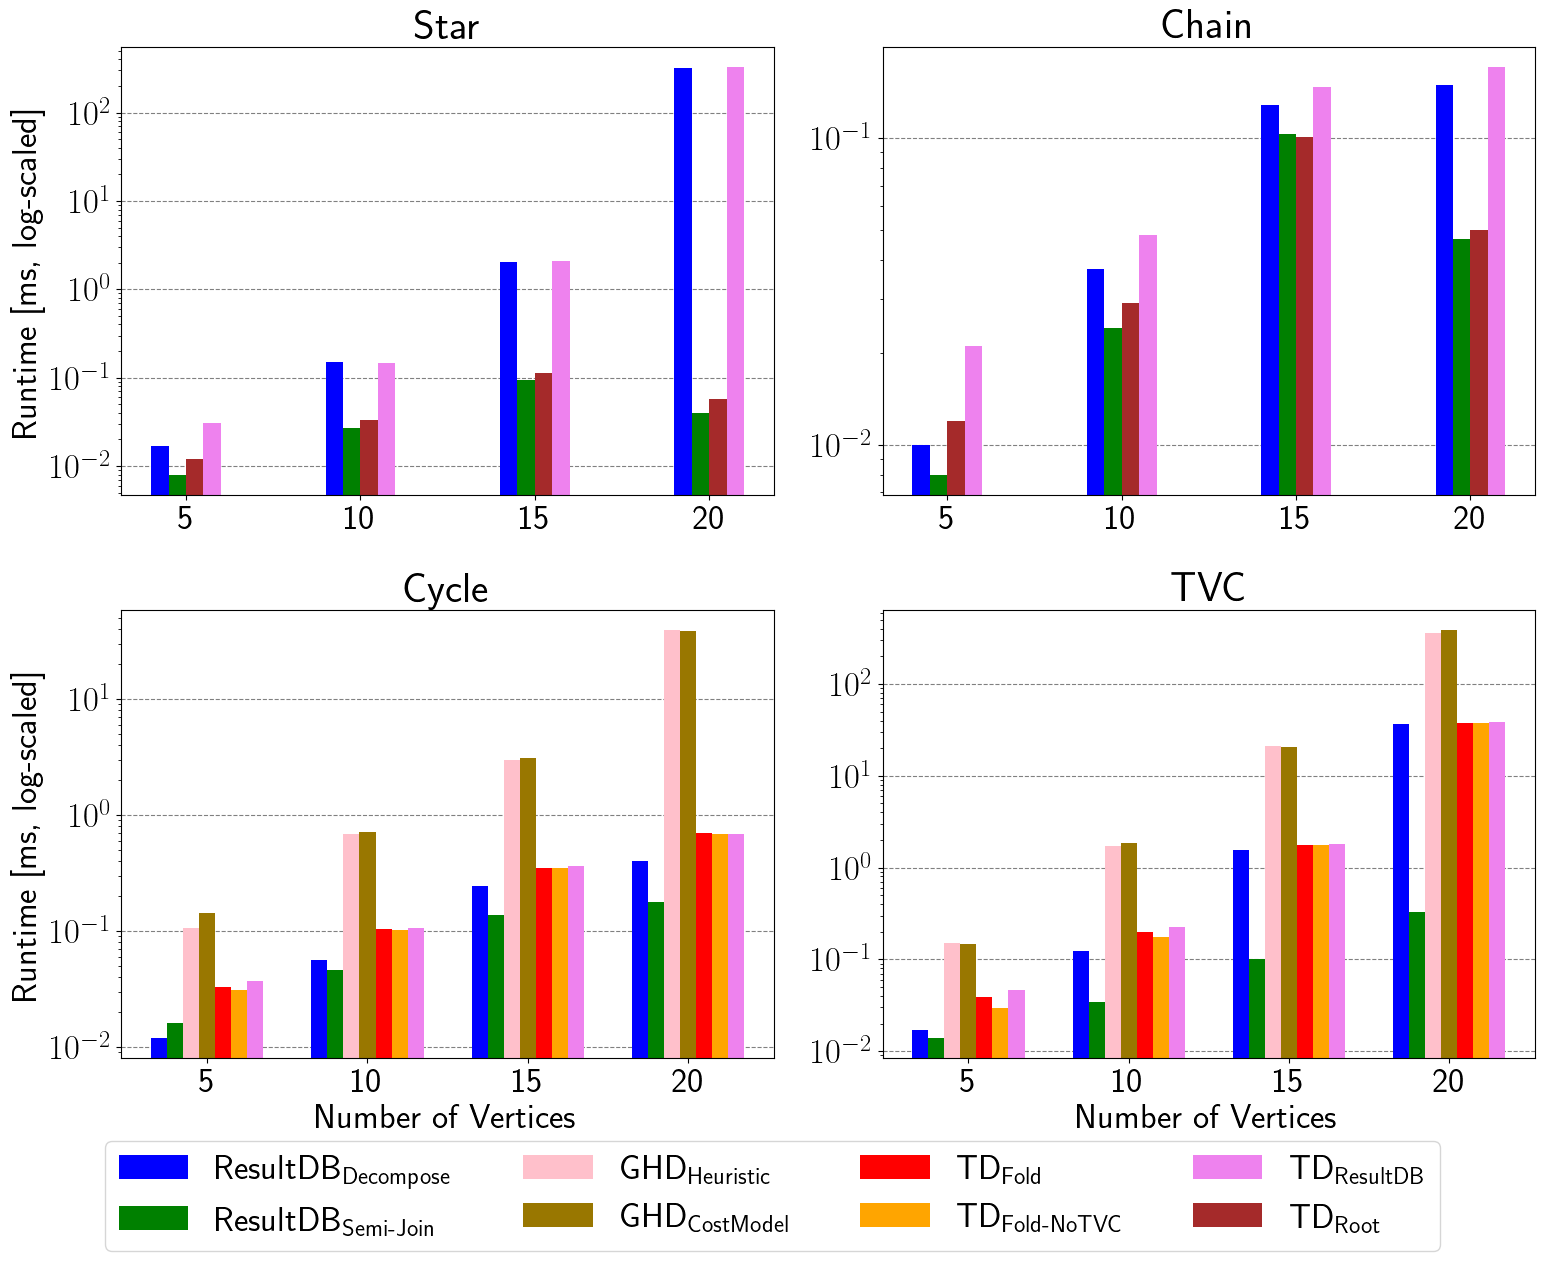

In [8]:
plt.rcParams['font.size'] = '25'
fig, axes = plt.subplots(2, 2, layout='constrained', figsize=(16,12))
ax_paths = [(axes[1,0], f'./enumeration_time/{result_path}/cycle.csv', cyclic_algorithms), (axes[0, 0], f'./enumeration_time/{result_path}/star.csv', acyclic_algorithms), (axes[0, 1], f'./enumeration_time/{result_path}/chain.csv', acyclic_algorithms), (axes[1,1], f'./enumeration_time/{result_path}/tvc.csv', cyclic_algorithms)]

width = 0.1
lines = dict()
nums = [5, 10, 15, 20]
for (ax, path, algorithm) in ax_paths:
    _ = create_ax_for_benchmark(ax, path, algorithm, width, lines, nums, nums, 'case')

# Y Axis
axes[0,0].set_ylabel('Runtime [ms, log-scaled]')
axes[1,0].set_ylabel('Runtime [ms, log-scaled]')

# X Axis
axes[1,0].set_xlabel('Number of Vertices')
axes[1,1].set_xlabel('Number of Vertices')

# Titles
axes[0][0].set_title('Star')
axes[0][1].set_title('Chain')
axes[1][0].set_title('Cycle')
axes[1][1].set_title('TVC')

handles = list(lines.values())
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.show()

fig.savefig(f'./enumeration_time/{result_path}/enumeration_time.pdf', bbox_inches='tight')


# Synthetic Experiments

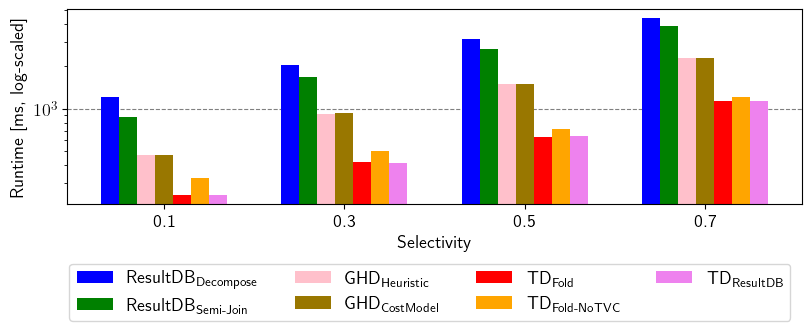

In [25]:
plt.rcParams['font.size'] = '13'
fig, ax = plt.subplots(layout='constrained', figsize=(8,2.5))
# ensure that `queries` is sorted!
queries = list(reversed([
    3,
    5,
    7,
    9,
]))
query_labels = list(reversed([0.7, 0.5, 0.3, 0.1]))
lines = dict()
create_ax_for_benchmark(ax, f'./synthetic/{result_path}/tvc_synthetic.csv', cyclic_algorithms, width, lines, queries, query_labels, 'case')
handles = list(lines.values())
labels = [h.get_label() for h in handles]
ax.set_ylabel('Runtime [ms, log-scaled]')
ax.set_xlabel('Selectivity')
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.53, -0.3))

fig.savefig(f'./synthetic/{result_path}/tvc_synthetic_benchmark_results.pdf', bbox_inches='tight')


Max: 1.5548751042626983
Min: 0.9290548424737455
Mean: 1.203796171053052


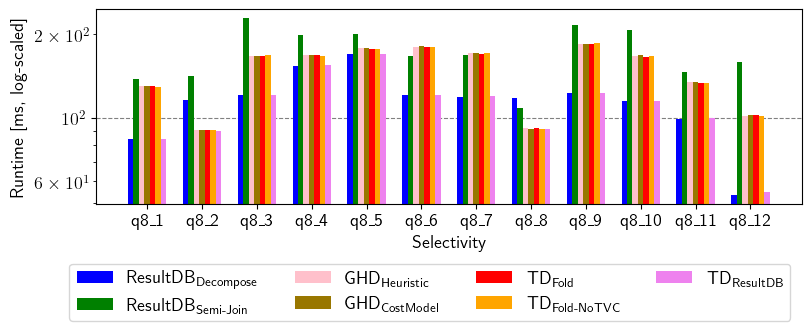

In [10]:
plt.rcParams['font.size'] = '13'
fig, ax = plt.subplots(layout='constrained', figsize=(8,2.5))
# ensure that `queries` is sorted!
queries = [
        "q8_1",
        "q8_2", "q8_3",
        "q8_4", "q8_5", "q8_6", "q8_7", "q8_8", "q8_9", "q8_10", "q8_11", "q8_12"
]
algorithms = copy.deepcopy(cyclic_algorithms)
lines = dict()
times = create_ax_for_benchmark(ax, f'./ce/{result_path}/results.csv', algorithms, width, lines, queries, queries, 'experiment', True)
handles = list(lines.values())
labels = [h.get_label() for h in handles]
ax.set_ylabel('Runtime [ms, log-scaled]')
ax.set_xlabel('Selectivity')
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.53, -0.3))

all_ = []
for i in range(len(queries)):
    all_.append(1 / (times['TD_Fold'][i] / times['ResultDB_SemiJoin'][i]))
print(f"Max: {max(all_)}")
print(f"Min: {min(all_)}")
print(f"Mean: {statistics.mean(all_)}")

fig.savefig(f'./ce/{result_path}/ce_benchmark_results.pdf', bbox_inches='tight')

    experiment                                       name          config  \
0         q10c  mutable (single core, ResultDB_Decompose)  Execution Time   
1         q10c   mutable (single core, ResultDB_SemiJoin)  Execution Time   
2         q10c         mutable (single core, TD_ResultDB)  Execution Time   
3         q10c             mutable (single core, TD_Root)  Execution Time   
4         q11c  mutable (single core, ResultDB_Decompose)  Execution Time   
..         ...                                        ...             ...   
99         q8a             mutable (single core, TD_Root)  Execution Time   
100        q9c  mutable (single core, ResultDB_Decompose)  Execution Time   
101        q9c   mutable (single core, ResultDB_SemiJoin)  Execution Time   
102        q9c         mutable (single core, TD_ResultDB)  Execution Time   
103        q9c             mutable (single core, TD_Root)  Execution Time   

     case     time  
0       0   51.848  
1       0  294.733  
2       0   

/var/folders/9n/q6f4_f3x1v10_ss5pw11tkww0000gn/T/ipykernel_97823/2906154352.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


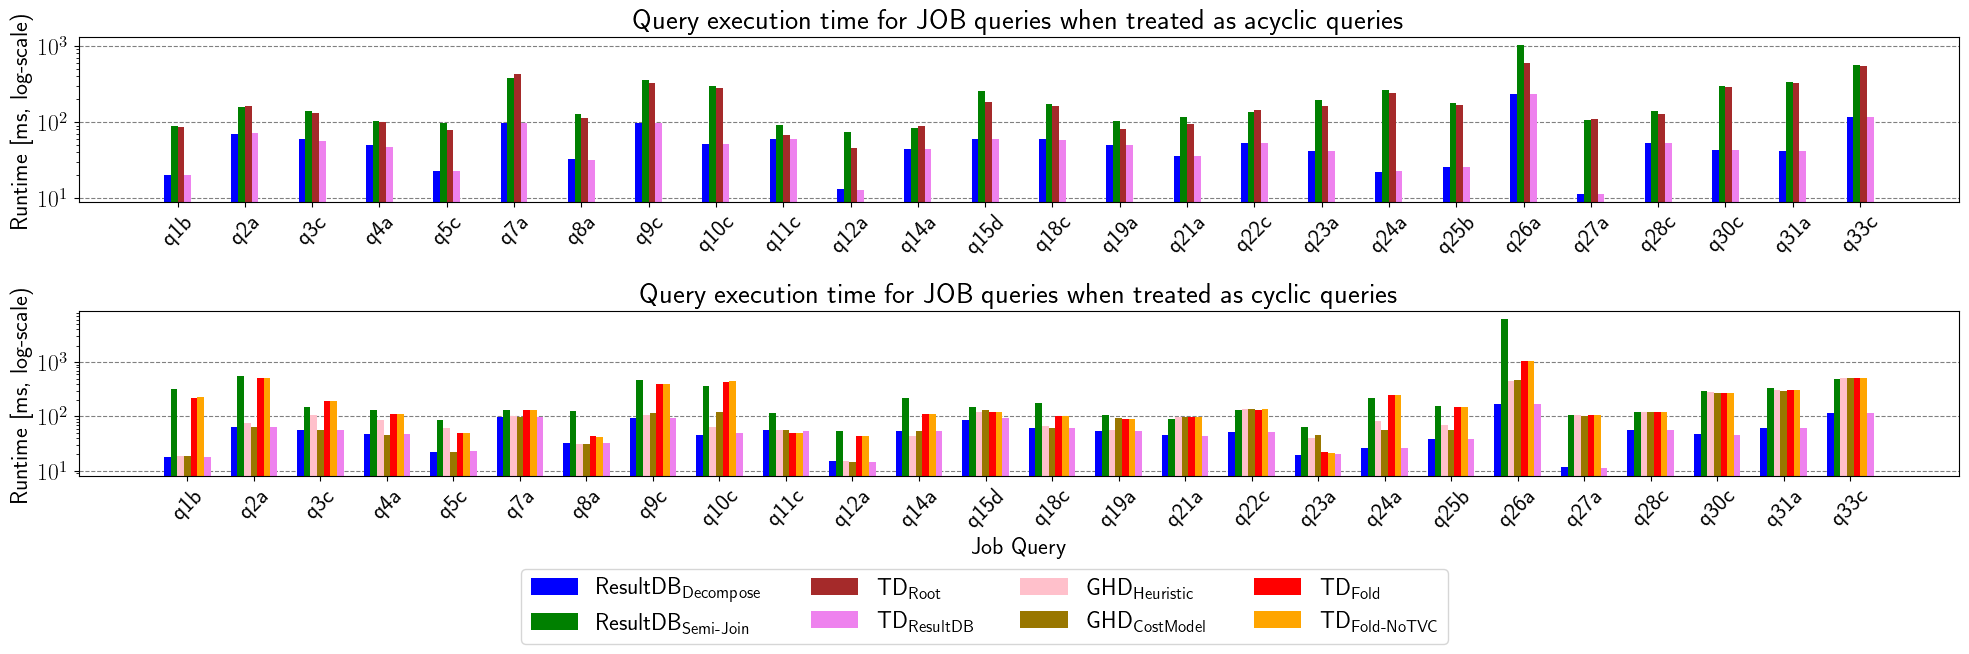

In [9]:
plt.rcParams['font.size'] = '17'
fig, (ax1, ax2) = plt.subplots(nrows=2, layout='constrained', figsize=(20,6))
ax_paths = [(ax1, f'./job/{result_path}/acyclic_results.csv', acyclic_algorithms), (ax2, f'./job/{result_path}/cyclic_results.csv', cyclic_algorithms)]

width = 0.1
lines = dict()
queries = [
    "q1b",
    "q2a",
    "q3c",
    "q4a",
    "q5c",
    "q7a",
    "q8a",
    "q9c",
    "q10c",
    "q11c",
    "q12a",
    "q14a",
    "q15d",
    "q18c",
    "q19a",
    "q21a",
    "q22c",
    "q23a",
    "q24a",
    "q25b",
    "q26a",
    "q27a",
    "q28c",
    "q30c",
    "q31a",
    "q33c"
]
times = None
for (ax, path, algorithm) in ax_paths:
    times_1 = times
    times = create_ax_for_benchmark(ax, path, algorithm, width, lines, queries, queries, 'experiment')
    ax.tick_params(axis='x', rotation=45)

# Y Axis
ax1.set_ylabel('Runtime [ms, log-scale)')
ax2.set_ylabel('Runtime [ms, log-scale)')

# X Axis
ax2.set_xlabel('Job Query')

# Titles
ax1.set_title('Query execution time for JOB queries when treated as acyclic queries')
ax2.set_title('Query execution time for JOB queries when treated as cyclic queries')

handles = list(lines.values())
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.12))

all_ = []
for i in range(len(queries)):
    all_.append(1 / (times['TD_Fold'][i] / times['ResultDB_SemiJoin'][i]))
print(f"Max: {max(all_)}")
print(f"Min: {min(all_)}")
print(f"Mean: {statistics.mean(all_)}")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig.savefig(f'./job/{result_path}/results.pdf', bbox_inches='tight')